Imports and paths

In [1]:
import numpy as np
import pandas as pd

DATA_DIR = "../data/processed"
TF = "1h"  # change to 4h, 1d, etc. if needed

prefix = f"btc_{TF}_featured_"

X_path = f"{DATA_DIR}/{prefix}labels_X.npy"
y_path = f"{DATA_DIR}/{prefix}labels_y.npy"
t_path = f"{DATA_DIR}/{prefix}labels_t.npy"
label_cols_path = f"{DATA_DIR}/{prefix}label_cols.npy"


Load arrays

In [2]:
X = np.load(X_path)
y = np.load(y_path)
t = np.load(t_path)
label_cols = np.load(label_cols_path)

print("X shape:", X.shape)      # (num_windows, window_size, num_features)
print("y shape:", y.shape)      # (num_windows, num_horizons)
print("t shape:", t.shape)
print("label_cols:", label_cols)



X shape: (54183, 48, 21)
y shape: (54183, 4)
t shape: (54183,)
label_cols: ['label_1h' 'label_4h' 'future_return_1h' 'future_return_4h']


In [3]:
import pandas as pd

i = 10000
print("Window time:", pd.to_datetime(t[i]))
print("Labels:", dict(zip(label_cols, y[i])))


Window time: 2021-02-26 12:00:00
Labels: {'label_1h': -2, 'label_4h': 2, 'future_return_1h': 0, 'future_return_4h': 0}


Inspect label distributions

In [4]:
for i, col in enumerate(label_cols):
    vals, counts = np.unique(y[:, i], return_counts=True)
    dist = dict(zip(vals, counts))
    print(f"{col} distribution:", dist)


label_1h distribution: {-2: 3172, -1: 19739, 0: 7519, 1: 20373, 2: 3380}
label_4h distribution: {-2: 4921, -1: 17300, 0: 8419, 1: 18223, 2: 5320}
future_return_1h distribution: {0: 54183}
future_return_4h distribution: {0: 54183}


Quick sanity check on one sample

In [6]:
idx = 19000  # pick a window index
print("Timestamp:", pd.to_datetime(t[idx]))
print("Labels:", {label_cols[i]: int(y[idx, i]) for i in range(len(label_cols))})

# Show last few timesteps of close + returns for context
df_sample = pd.DataFrame(
    X[idx],
    columns=[
        "open", "high", "low", "close", "volume",
        "returns", "hl_range", "hl_pct",
        "volatility", "volatility_short",
        "sma_20", "sma_50", "sma_ratio",
        "rsi", "macd", "macd_signal", "macd_histogram",
        "bb_width", "bb_position",
        "volume_ratio", "price_position",
    ],
)
df_sample.tail()


Timestamp: 2022-03-09 16:00:00
Labels: {'label_1h': 1, 'label_4h': -1, 'future_return_1h': 0, 'future_return_4h': 0}


,open,high,low,close,volume,returns,hl_range,hl_pct,volatility,volatility_short,...,sma_50,sma_ratio,rsi,macd,macd_signal,macd_histogram,bb_width,bb_position,volume_ratio,price_position
43,42151.648438,42545.449219,41626.859375,41914.328125,4061.988525,-0.005630,918.590027,2.191589,1.113798,0.468799,...,39229.402344,1.027924,73.619987,931.178894,763.557617,167.621323,14.466068,0.762149,1.385643,0.882919
44,41914.328125,42082.910156,41650.140625,41869.160156,2727.610596,-0.001078,432.769989,1.033625,1.116631,0.444813,...,39300.042969,1.029635,72.616661,903.869873,791.620056,112.249809,14.548326,0.730572,0.955672,0.874539
45,41869.160156,42308.648438,41850.000000,42208.710938,3654.849365,0.008110,458.649994,1.086624,1.113232,0.497252,...,39372.292969,1.032223,75.337608,899.259949,813.148010,86.111931,14.313334,0.759494,1.285935,0.937530
46,42208.710938,42594.058594,42106.808594,42520.988281,3299.684814,0.007398,487.250000,1.145905,1.107384,0.556640,...,39442.199219,1.035155,77.547279,910.311462,832.580688,77.730759,14.100248,0.782242,1.144924,0.986566
47,42520.988281,42558.960938,42131.179688,42233.160156,2247.112305,-0.006769,427.779999,1.012901,1.096762,0.634736,...,39509.917969,1.038089,71.213921,885.635376,843.191650,42.443707,13.535653,0.713125,0.773946,0.933647


Find an index where label_1h_5c == 2

In [7]:
import numpy as np

# Find column index for label_1h_5c
label_name = "label_1h"
label_idx = list(label_cols).index(label_name)

# Indices of windows where label_1h_5c == 2 (Bullish)
bull_idxs = np.where(y[:, label_idx] == 2)[0]
print("Found", len(bull_idxs), "bullish continuation windows")

# Pick one example index (e.g. the first one)
if len(bull_idxs) > 0:
    i = int(bull_idxs[0])
    print("Inspecting window index:", i)
else:
    i = None


Found 3380 bullish continuation windows
Inspecting window index: 0


Inspect that window (if found)

In [8]:
import pandas as pd

if i is not None:
    print("Timestamp:", pd.to_datetime(t[i]))
    print("Labels:", {label_cols[j]: int(y[i, j]) for j in range(len(label_cols))})

    df_sample = pd.DataFrame(
        X[i],
        columns=[
            "open", "high", "low", "close", "volume",
            "returns", "hl_range", "hl_pct",
            "volatility", "volatility_short",
            "sma_20", "sma_50", "sma_ratio",
            "rsi", "macd", "macd_signal", "macd_histogram",
            "bb_width", "bb_position",
            "volume_ratio", "price_position",
        ],
    )
    df_sample.tail(10)  # last 10 candles of the window


Timestamp: 2020-01-05 00:00:00
Labels: {'label_1h': 2, 'label_4h': 1, 'future_return_1h': 0, 'future_return_4h': 0}


In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/btc_5m_features.csv")
df["open_time"] = pd.to_datetime(df["open_time"], utc=True)
df = df.set_index("open_time").sort_index()

# Future closes for each horizon (in 5m steps)
steps = {
    "5m": 1,      # 1 * 5m
    "15m": 3,     # 3 * 5m
    "1h": 12,     # 12 * 5m
    "4h": 48,     # 48 * 5m
    "1d": 288,
    "1w": 2016,
}

for h, n in steps.items():
    df[f"close_{h}_future"] = df["close"].shift(-n)
    df[f"ret_{h}"] = df[f"close_{h}_future"] / df["close"] - 1

# drop rows where any ret_* is NaN
ret_cols = [f"ret_{h}" for h in steps]
df = df.dropna(subset=ret_cols)

percentile = 90  # choose once, applied to all horizons
thresholds = {}

for col in ret_cols:
    thr = np.percentile(np.abs(df[col].values), percentile)
    thresholds[col] = thr
    print(col, "threshold:", thr)

# drop rows where any ret_* is NaN
ret_cols = [f"ret_{h}" for h in steps]
df = df.dropna(subset=ret_cols)

percentile = 90  # choose once, applied to all horizons
thresholds = {}

for col in ret_cols:
    thr = np.percentile(np.abs(df[col].values), percentile)
    thresholds[col] = thr
    print(col, "threshold:", thr)

for col in ret_cols:
    print(f"\n{col} stats:")
    print(df[col].describe(percentiles=[0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99]))


ret_5m threshold: 0.0026403353950694482
ret_15m threshold: 0.004512329323870422
ret_1h threshold: 0.009060031506485353
ret_4h threshold: 0.0191632545408267
ret_1d threshold: 0.049140384600023894
ret_1w threshold: 0.1367516473154049
ret_5m threshold: 0.0026403353950694482
ret_15m threshold: 0.004512329323870422
ret_1h threshold: 0.009060031506485353
ret_4h threshold: 0.0191632545408267
ret_1d threshold: 0.049140384600023894
ret_1w threshold: 0.1367516473154049

ret_5m stats:
count    649755.000000
mean          0.000006
std           0.002048
min          -0.102254
1%           -0.005546
5%           -0.002633
10%          -0.001732
50%           0.000000
90%           0.001750
95%           0.002649
99%           0.005568
max           0.184288
Name: ret_5m, dtype: float64

ret_15m stats:
count    649755.000000
mean          0.000016
std           0.003459
min          -0.127890
1%           -0.009676
5%           -0.004491
10%          -0.002912
50%           0.000009
90%           0.

In [10]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/btc_5m_features.csv")
df["open_time"] = pd.to_datetime(df["open_time"], utc=True)
df = df.set_index("open_time").sort_index()

steps = {
    "5m": 1,
    "15m": 3,
    "1h": 12,
    "4h": 48,
    "1d": 288,
    "1w": 2016,
}

for h, n in steps.items():
    df[f"close_{h}_future"] = df["close"].shift(-n)
    df[f"ret_{h}"] = df[f"close_{h}_future"] / df["close"] - 1

ret_cols = [f"ret_{h}" for h in steps]
df = df.dropna(subset=ret_cols)

percentile = 90
thresholds = {}

for col in ret_cols:
    thr = np.percentile(np.abs(df[col].values), percentile)
    thresholds[col] = thr
    print(col, "90th pct threshold:", thr, "=>", round(thr * 100, 3), "%")




ret_5m 90th pct threshold: 0.0026403353950694482 => 0.264 %
ret_15m 90th pct threshold: 0.004512329323870422 => 0.451 %
ret_1h 90th pct threshold: 0.009060031506485353 => 0.906 %
ret_4h 90th pct threshold: 0.0191632545408267 => 1.916 %
ret_1d 90th pct threshold: 0.049140384600023894 => 4.914 %
ret_1w 90th pct threshold: 0.1367516473154049 => 13.675 %


In [11]:
import pandas as pd
import numpy as np

files = {
    "5m": "../data/processed/btc_5m_features.csv",
    "15m": "../data/processed/btc_15m_features.csv",
    "1h": "../data/processed/btc_1h_features.csv",
    "4h": "../data/processed/btc_4h_features.csv",
    "1d": "../data/processed/btc_1d_features.csv",
    "1w": "../data/processed/btc_1w_features.csv",
}

percentile = 90
thresholds = {}

for tf, path in files.items():
    df = pd.read_csv(path)
    df["open_time"] = pd.to_datetime(df["open_time"], utc=True)
    df = df.set_index("open_time").sort_index()

    # assume each file already has its own close column
    df["ret"] = df["close"].shift(-1) / df["close"] - 1     # 1-step ahead for that TF
    df = df.dropna(subset=["ret"])

    thr = np.percentile(np.abs(df["ret"].values), percentile)
    thresholds[tf] = thr
    print(tf, "90th pct threshold:", thr, "=>", round(thr * 100, 3), "%")


5m 90th pct threshold: 0.002639694059995577 => 0.264 %
15m 90th pct threshold: 0.004494635483073273 => 0.449 %
1h 90th pct threshold: 0.009143380058060924 => 0.914 %
4h 90th pct threshold: 0.019397297634400273 => 1.94 %
1d 90th pct threshold: 0.04970957871797939 => 4.971 %
1w 90th pct threshold: 0.126054026787271 => 12.605 %


Test future_return_1h vs prediction

       target_return  predicted_return
count    8128.000000       8128.000000
mean        0.000014         -0.000225
std         0.003076          0.000425
min        -0.006000         -0.001671
25%        -0.003000         -0.000518
50%         0.000000         -0.000266
75%         0.003000          0.000009
max         0.006000          0.002584


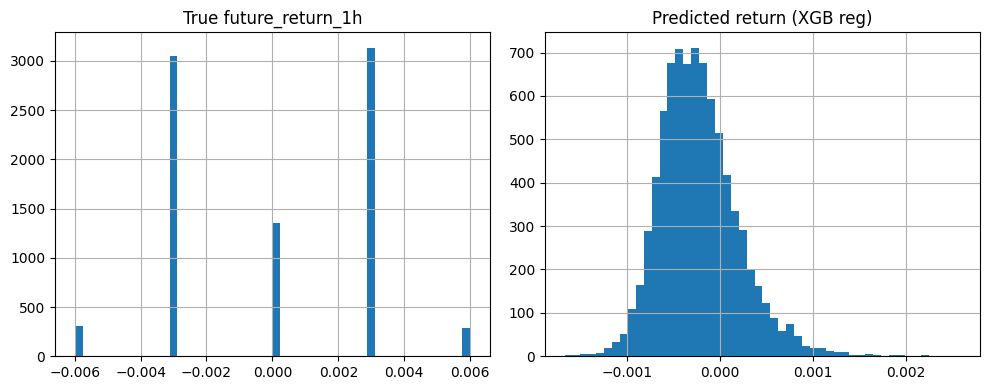

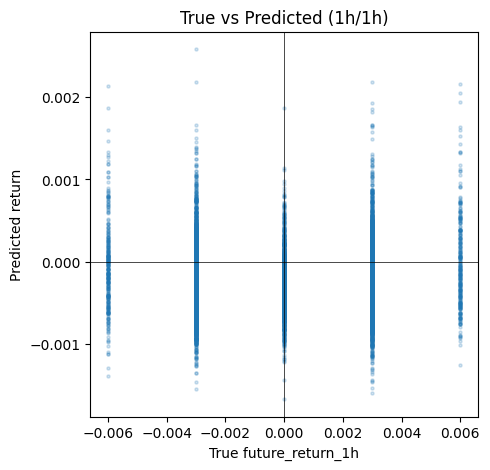

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Load regression predictions
reg_path = "../models/predictions/1h_1h_xgb_reg_test_reg_predictions.csv"
reg = pd.read_csv(reg_path)

# Basic stats
print(reg[['target_return', 'predicted_return']].describe())

# Histogram of true vs predicted
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
reg['target_return'].hist(bins=50)
plt.title('True future_return_1h')

plt.subplot(1,2,2)
reg['predicted_return'].hist(bins=50)
plt.title('Predicted return (XGB reg)')
plt.tight_layout()
plt.show()

# Scatter: true vs predicted
plt.figure(figsize=(5,5))
plt.scatter(reg['target_return'], reg['predicted_return'], alpha=0.2, s=5)
plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(0, color='k', linewidth=0.5)
plt.xlabel('True future_return_1h')
plt.ylabel('Predicted return')
plt.title('True vs Predicted (1h/1h)')
plt.show()

signal_experiments - Test future price prediction

In [22]:
# Load classifier predictions
clf_path = "../models/predictions/1h_1h_xgb_test_predictions.csv"
clf = pd.read_csv(clf_path)

# Merge on index (both are aligned test sets)
merged = clf.join(reg, lsuffix="_clf", rsuffix="_reg")

# Optionally map class index back to signed direction
IDX_TO_DIR = {0: -2, 1: -1, 2: 0, 3: 1, 4: 2}
merged['dir_pred'] = merged['y_pred'].map(IDX_TO_DIR)

# Define a simple trading rule
THRESH = 0.0015  # 0.2%
def signal_row(r):
    if r['predicted_return'] > THRESH and r['dir_pred'] > 0:
        return 1   # long
    if r['predicted_return'] < -THRESH and r['dir_pred'] < 0:
        return -1  # short
    return 0       # flat

merged['signal'] = merged.apply(signal_row, axis=1)

# Realized PnL proxy using true future_return_1h (target_return)
merged['pnl'] = merged['signal'] * merged['target_return']

print("Mean PnL per trade:", merged.loc[merged['signal'] != 0, 'pnl'].mean())
print("Hit rate:", (merged['pnl'] > 0).mean())
print("Trades:", (merged['signal'] != 0).sum())

Mean PnL per trade: 0.0015000000000000002
Hit rate: 0.0012303149606299212
Trades: 16
